# Simple Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
# reading data
df = pd.read_csv("./FuelConsumption.csv")

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
df["TRANSMISSION"].head()

0    AS5
1     M6
2    AV7
3    AS6
4    AS6
Name: TRANSMISSION, dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [6]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]

cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


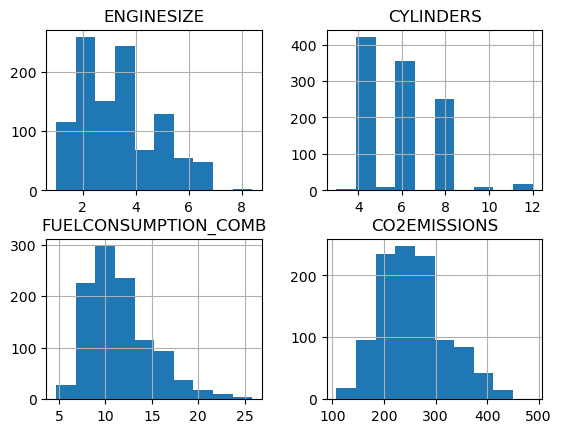

In [8]:
viz = cdf[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
viz.hist()
plt.show()

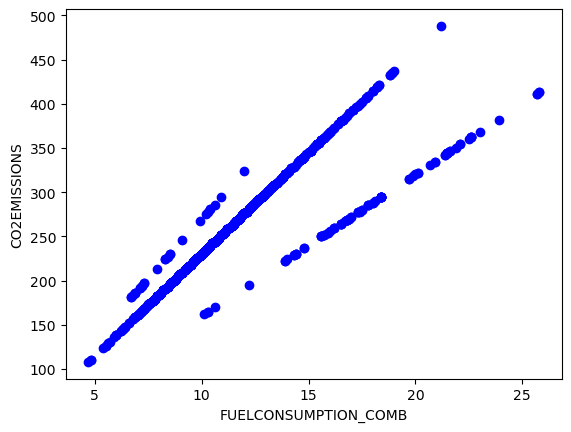

In [9]:
plt.scatter(cdf["FUELCONSUMPTION_COMB"], cdf["CO2EMISSIONS"], color="blue")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.show()

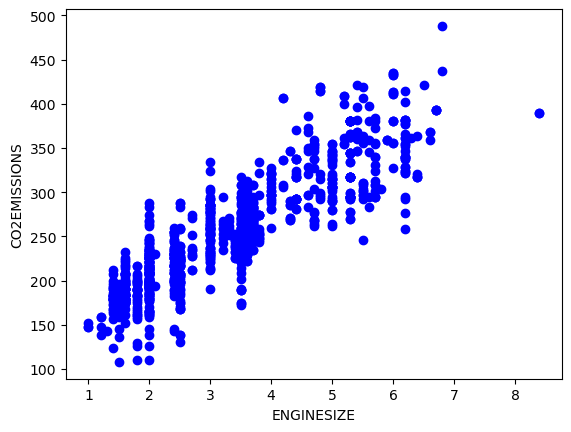

In [10]:
plt.scatter(cdf["ENGINESIZE"], cdf["CO2EMISSIONS"], color="blue")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

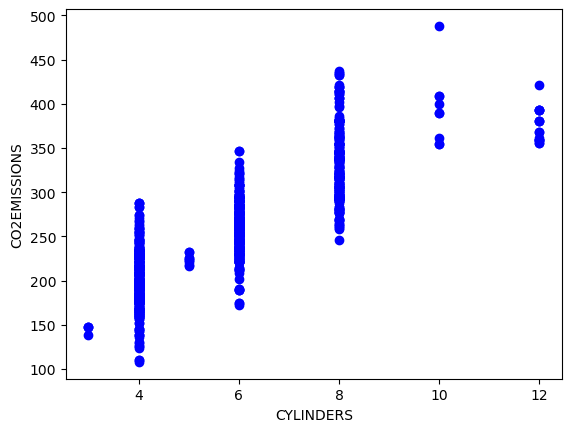

In [11]:
plt.scatter(cdf["CYLINDERS"], cdf["CO2EMISSIONS"], color="blue")
plt.xlabel("CYLINDERS")
plt.ylabel("CO2EMISSIONS")
plt.show()

In [12]:
np.random.rand()

0.3329918335705563

In [13]:
# spliting data into train and test sets using numpy

msk = np.random.rand(len(cdf)) < 0.8
train = cdf[msk]
test = cdf[~msk]

print(msk)
print(~msk)

print(f'train size: {len(train)}')
print(f'test size: {len(test)}')

[ True False  True ...  True False  True]
[False  True False ... False  True False]
train size: 860
test size: 207


Text(0, 0.5, 'CO2EMISSIONS')

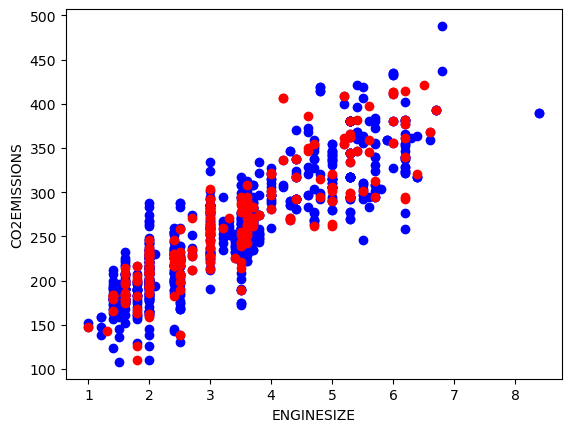

In [14]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
ax.set_xlabel("ENGINESIZE")
ax.set_ylabel("CO2EMISSIONS")

ax.scatter(test.ENGINESIZE, test.CO2EMISSIONS, color="red")
ax.set_xlabel("ENGINESIZE")
ax.set_ylabel("CO2EMISSIONS")

In [15]:
model = LinearRegression()
train_x = np.asanyarray(train[["ENGINESIZE"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])
model.fit(train_x, train_y)

coef = model.coef_
intercept = model.intercept_

print(f"Coefficient: {coef} Intercept: {intercept}")

Coefficient: [[38.80563669]] Intercept: [125.67072407]


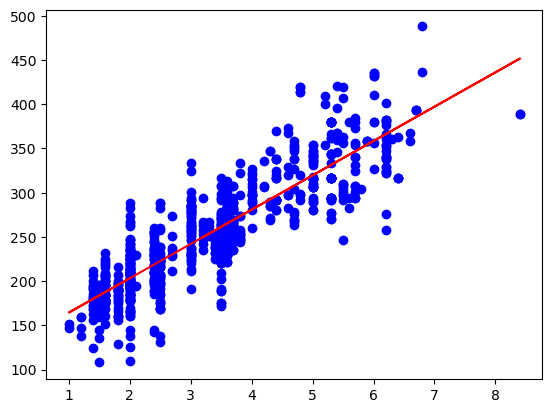

In [16]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
plt.plot(train_x, model.coef_[0][0] * train_x + model.intercept_[0], "-r")

In [17]:
test_x = np.asanyarray(test[["ENGINESIZE"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
predict_result = model.predict(test_x)

mae = np.mean(np.absolute(predict_result - test_y))
mse = np.mean(np.square(predict_result - test_y))
r2 = r2_score(test_y, predict_result)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 score: {r2}")

MAE: 23.125034891601487
MSE: 977.3327490723517
R2 score: 0.7761122729851585


In [18]:
random_enginesize = 8
predicted_emission = model.predict([[random_enginesize]])
print(f"For a Machine with engine size {random_enginesize}, the predicted CO2 emission is {predicted_emission[0][0]}")

For a Machine with engine size 8, the predicted CO2 emission is 436.11581758709616


# Multiple Linear Regression

In [26]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "FUELCONSUMPTION_CITY",
          "FUELCONSUMPTION_HWY", "FUELCONSUMPTION_COMB_MPG", "CO2EMISSIONS"]]

cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,8.5,9.9,6.7,33,196
1,2.4,4,9.6,11.2,7.7,29,221
2,1.5,4,5.9,6.0,5.8,48,136
3,3.5,6,11.1,12.7,9.1,25,255
4,3.5,6,10.6,12.1,8.7,27,244
5,3.5,6,10.0,11.9,7.7,28,230
6,3.5,6,10.1,11.8,8.1,28,232
7,3.7,6,11.1,12.8,9.0,25,255
8,3.7,6,11.6,13.4,9.5,24,267


In [ ]:
# data splitting
msk = np.random.rand(len(cdf)) < 0.8
train = cdf[msk]
test = cdf[~msk]

In [ ]:
# training
multiple_model = LinearRegression()
train_x = np.asanyarray(train[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])

multiple_model.fit(train_x, train_y)
coef = multiple_model.coef_
intercept = multiple_model.intercept_    

print(f"Coefficient: {coef} Intercept: {intercept}")

Coefficient: [[11.06158676  7.35964815  9.49546603]] Intercept: [66.45492019]


In [35]:
# prediction
test_x = np.asanyarray(test[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
pred_y = multiple_model.predict(test_x)

print(f"Residual sum of squares: {np.mean((pred_y - test_y) ** 2)}")

print(f"R2 score: {multiple_model.score(test_x, test_y)}")

Residual sum of squares: 601.5727386903544
R2 score: 0.8574249045330022


In [39]:
# training
multiple_model_2 = LinearRegression()
train_x = np.asanyarray(
    train[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB_MPG",]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])

multiple_model_2.fit(train_x, train_y)
coef = multiple_model_2.coef_
intercept = multiple_model_2.intercept_

print(f"Coefficient: {coef} Intercept: {intercept}")

# prediction
test_x = np.asanyarray(
    test[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB_MPG",]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
pred_y = multiple_model_2.predict(test_x)

print(f"Residual sum of squares: {np.mean((pred_y - test_y) ** 2)}")

print(f"R2 score: {multiple_model_2.score(test_x, test_y)}")

Coefficient: [[11.05959     6.07656795 -4.88104943]] Intercept: [312.91138811]
Residual sum of squares: 523.8920292604776
R2 score: 0.8758355369479953
